# Искусственная нейронная сеть
Искусственная нейронная сеть (artificial neural network, ANN) представляет собой (значительно) упрощенную модель естественной нейронной сети.
## Модель естественного нейрона

Рассмотрим модель естественного нейрона (https://en.wikipedia.org/wiki/Artificial_neuron).

![](https://drive.google.com/uc?export=view&id=1Szuu0l6k5TavkBfQoxFMr22Y5b968IrO)

Сигнал (небольшой электрический импульс) поступает на разветвленные отростки, называемые *дендритами*, аккумулируется в соме (теле клетки) и, если его суммарное значение превосходит некоторый порог, генерирует импульс, проходящий по аксону в синапсы, соединенные с дендритами другой нервной клетки.

Синапсы имеют разную способность пропускать импульс и соответственно передают заряды различной величины следующим нейронам.

## Модель МакКаллока-Питтса

Именно эту сильно упрощенную схему действия естественного нейрона взяли за основу МакКаллок и Питтс (McCulloch and Walter Pitts model).

![](https://drive.google.com/uc?export=view&id=1BIgCE2mHQ1-WnBBHl1PPx3suBUqsnjWs)

Они предложили использовать вектор бинарных признаков $\mathbf x = (x_1, \ldots,
x_n)$ (сигнал, поступающий в дендриты) и вектор соответствующих весов $\mathbf
w = (w_1, \ldots, w_n)$ (способность синапсов пропускать импульс), которые бы
генерировали суммарное значение (импульса).

$$ z = w_1 x_1 + \ldots + w_n x_n = \sum^n_{j=1} w_i x_i = \mathbf w^\top \mathbf x
$$

При достижении определенного порога $w_0$ сигнал бы либо передавался дальше
(выдавал единицу), либо не передавался (выдавал ноль).

$$ g(z) =\begin{cases} 1 & \text{если } \mathbf{z} \gt w_0 \\ 0 & \text{если }
\mathbf{z} \leq w_0. \end{cases} $$

Перенесем $w_0$ в левую часть неравенства и добавим признак $x_0 = -1.$ Тогда,

$$ z = w_0 x_{0} + w_1 x_1 + \ldots + w_n x_n = \sum_{j=0}^{n} x_{j} w_{j} \ =
\mathbf{w}^\top \mathbf {x} $$

$$ g(z) =\begin{cases} 1 & \text{если } \mathbf{z} \gt 0 \\ 0 & \text{если } \mathbf{z}
\leq 0, \end{cases} $$

где $g$ — ступенчатая функция Хевисайда (**Heaviside step function** или **unit step function**).

Функция Хевисайда в общем случае называется **функцией активации** (activation function) и может быть заменена на другую функцию, в частности, сигнум-функцию или сигмоиду.

##Линейный классификатор

Сведем задачу классификации к построению элементарной логической функции И.

![](https://drive.google.com/uc?export=view&id=1aTEEANNIhsJAznPRYcttTTi8J3vOgMA2)

Решающая граница может быть задана, в частности, уравнением

$$ 2x_1 + 2x_2-3 = 0,$$

что соответствует искусственной нейросети с двумя входящими сигналами $ x_1,
x_2 \in \{0, 1\} $ и функции активации Хевисайда.

![](https://drive.google.com/uc?export=view&id=1h0gnj_QnPiTfPnDWoqM-sDCw81Xdxdm2)

Аналогичным образом можно построить границу для логического ИЛИ.

$$ 2x_1 + 2x_2-1 = 0$$

Несложно построить и логическое НЕ.

$$ 2x_1-1 = 0$$

![](https://drive.google.com/uc?export=view&id=174235xJjdhk7zmL_AwPRfmz2_xOpv2MO)



## Персептрон Розенблатта

Остается открытым вопрос о том, как автоматически подбирать веса

Вновь проводя аналогию с естественной нейронной сетью, заметим, что при запоминании информации «правильные» связи между нейронами сохраняются, а «неправильные» — исчезают.
### Правило Хэбба

Посмотрим, как это правило можно формализовать с помощью искусственной
нейронной сети. Возьмем набор данных $\mathcal{D} = \{\mathbf{x}_i,
y_i\}_{i=1}^N$ и преобразуем для удобства метки классов

$$ y \in \{0, 1\} \rightarrow \{ -1, +1 \} $$

Вначале положим $\mathbf w$ равными нулю. Для построения разделяющей
границы нам необходимо найти такие $\mathbf w$, чтобы

$$ \begin{cases} \mathbf w^\top \mathbf x \gt 0 & \text{если } y = +1 \\ \mathbf w^\top
\mathbf x \leq 0 & \text{если } y = -1. \end{cases} $$

Заменим функцию Хевисайда на сигнум-функцию

$$ g(z) = sgn(\mathbf w^\top \mathbf x), $$

которая будет выдавать $+1,$ если скарярное произведение положительно, и $-1,$
если отрицательно, и тогда,
* если значение $g(z)$ совпадет с меткой класса, мы оставим веса $\mathbf w$
без изменений, т.е. сохраним синаптическую связь; но
* если не совпадет — изменим связь между нейронами, и, в частности,
  * если $y = +1$ и $g(z) = -1,$ прибавим вектор $\mathbf x$ к вектору
$\mathbf w;$
  * если $y = -1$ и $g(z) = +1,$ вычтем вектор $\mathbf x$ из вектора
$\mathbf w.$

Такое правило обновления весов удобно записать следующим образом

$$ \mathbf w := \mathbf w + \Delta \mathbf w $$

$$ \Delta \mathbf w = \eta \; (y_i-g(z)_i) \; \mathbf x_i, $$

где $\mathbf x_i$ — один из $N$ объектов, $y_i$ — соответствующая метка класса, $g(z)_i$ — прогноз для $ \mathbf x_i$ объекта и $\eta$ — коэффициент скорости
обучения. В самом деле,
* если значение $g(z)_i$ совпадает с меткой класса, то $(y_i-g(z)_i)$ будет равно
нулю;
* если нет, то опять же возможны два сценария:
  * $\Delta \mathbf w = \eta(1_i-(-1_i))\; \mathbf x_{i} = \eta(2)\; \mathbf x_i$
  * $\Delta \mathbf w = \eta(-1_i-1_i)\; \mathbf x_{i} = \eta(-2)\; \mathbf x_i$

Почему это работает? Вспомним, что скалярное произведение характеризует угол
между векторами.

$$ \begin{split} \begin{array}{rc} \cos \theta &=& \frac {\mathbf w^\top \mathbf x}{||
\mathbf w || || \mathbf x ||} \\ & \propto & \mathbf w^\top \mathbf x \end{array}
\end{split} $$

В случае правильно классифицированных данных,
* если $\mathbf w^\top \mathbf x \gt 0 \implies \cos \theta \gt 0 \implies \theta \lt
90^{\circ};$
* если $\mathbf w^\top \mathbf x \lt 0 \implies \cos \theta \lt 0 \implies \theta \gt
90^{\circ}.$

Например,

![](https://drive.google.com/uc?export=view&id=1EUKEtCp6LBNKbAWvVensWYigVbKjMkhi)

Если же данные классифицированы неправильно, то в случае если мы прибавляем
вектор $\mathbf x$ к вектору $\mathbf w,$ то есть $ \mathbf w^{\prime} = \mathbf w +
\mathbf x, $ то $\cos \theta^{\prime}$ будет больше $\cos \theta$

$$ \begin{split} \begin{array}{rl} \cos \theta^{\prime} &\propto& \mathbf w^{\prime
\top} \mathbf x \\ &\propto& (\mathbf w+\mathbf x)^\top \mathbf x \\ &\propto& \mathbf
w^\top +\mathbf x^\top \mathbf x \\ &\propto& \cos \theta+\mathbf x^\top \mathbf x \\
\cos \theta^{\prime} &\gt& \cos \theta \end{array} \end{split} $$

Таким образом, мы уменьшаем угол между положительным объектом-нарушителем
и вектором $\mathbf w.$ Например, на рисунке ниже, таким объектом является
вектор $\mathbf x^+_1.$

![](https://drive.google.com/uc?export=view&id=1Oyr0rVOwbUkP2htFLdPsHuyDl-Q8o8PR)

Сложив $\mathbf x^+_1$ и $\mathbf w$ мы повернем границу против часовой
стрелки и добьемся правильной классификации всех объектов. Аналогичное
рассуждение можно провести и для отрицательного объекта-нарушителя.

$$ \begin{split} \begin{array}{rl} \cos \theta^{\prime\prime} &\propto& \mathbf
w^{\prime\prime \top} \mathbf x \\ &\propto& (\mathbf w-\mathbf x)^\top \mathbf x \\
&\propto& \mathbf w^\top-\mathbf x^\top \mathbf x \\ &\propto& \cos \theta-\mathbf
x^\top \mathbf x \\ \cos \theta^{\prime\prime} &\lt& \cos \theta \end{array} \end{split}
$$

Такое правило обновления весов называется **правилом Хэбба** (Hebb’s rule), а сам
алгоритм — **персептроном Розенблатта** (Rosenblatt’s Perceptron).

### Теорема Новикова
В случае линейно разделимых данных для правила Хэбба доказана сходимость к
оптимальному $\mathbf w^*$ за конечное число $t$ шагов (Новиков, 1962).

**Доказательство.** Будем исходить из следующих допущений:

вектор $\mathbf w^0 = \mathbf 0$ — вектор весов на $t=0$ шаге;
* без ограничения общности положим $\eta = 1;$
* на шагах $t = (1, \ldots, T):$
  * если $y^t (\mathbf w^\top \mathbf x^t) \leq 0,$ обновим веса $ \mathbf
w^{t+1} = \mathbf w^t + y^t \mathbf x^t ;$
  * если $y^t (\mathbf w^\top \mathbf x^t) \gt 0,$ оставим веса без изменений
$\mathbf w^{t+1} = \mathbf w^t.$

Критерием сходимости будет выполнение $y_i (\mathbf w^{*\top} \mathbf x_i) \gt 0$
для каждого объекта $ \{ \mathbf{x}_i, y_i \}_{i=1}^N.$

Рассмотрим только те шаги, на которых алгоритм ошибается, а также для простоты
только класс $y=+1,$ поскольку мы всегда можем обобщить это правило умножив
на $y^t.$ Тогда,

$$ \mathbf w^{t+1} = \mathbf w^t + \mathbf x^t $$

и поскольку $\mathbf w^0 = \mathbf 0,$ то по индукции

$$ \begin{gather} \begin{array}{rl} \mathbf w^{1} &=& \mathbf x^0 \\ \mathbf w^{2}
&=& \mathbf x^1 + \mathbf x^0 \\ \ldots && \ldots \\ \mathbf w^{t+1} &=& \mathbf x^1
+ \mathbf x^2 + \ldots + \mathbf x^t \tag{1} \end{array} \end{gather} $$

В силу того что данные линейно разделимы, $\mathbf w^*$ существует, а значит

$$ \mathbf w^{*\top} \mathbf x^t > 0 \quad \text{для} \quad \mathbf x^1, \mathbf x^2,
\ldots, \mathbf x^t $$

Пусть $\alpha$ — положительное число, такое что $\alpha = \min \mathbf w^{*\top}
\mathbf x^t.$ Умножим обе части $(1)$ на $\mathbf w^{*\top}.$

$$ \underbrace{ \mathbf w^{*\top} \mathbf w^{t+1}}_{\geq t \alpha} = \underbrace{
\mathbf w^{*\top} \mathbf x^1}_{\geq \alpha} + \underbrace{ \mathbf w^{*\top}
\mathbf x^2 }_{\geq \alpha} + \ldots + \underbrace{ \mathbf w^{*\top} \mathbf x^t
}_{\geq \alpha} $$

$$ \mathbf w^{*\top} \mathbf w^{t+1} \geq t \alpha $$

По неравенству Коши-Буняковского,

$$ \begin{gather} \Vert \mathbf w^{*} \Vert^2 \Vert \mathbf w^{t+1} \Vert^2 &\geq& [
\mathbf w^{*\top} \cdot \mathbf w^{t+1} ]^2 \\ \Vert \mathbf w^{*} \Vert^2 \Vert
\mathbf w^{t+1} \Vert^2 &\geq& t^2 \alpha^2 \\ \Vert \mathbf w^{t+1} \Vert^2 &\geq&
\frac{t^2 \alpha^2}{\Vert \mathbf w^{*} \Vert^2} \tag{2} \end{gather} $$

Одновременно, поскольку согласно допущению мы рассматриваем только

ошибочно классифицированные объекты, то справедливо, что
$$ \mathbf w^{k+1} = \mathbf w^k + \mathbf x^k, \quad k = 1, \ldots, t. $$

Найдем евклидово расстояние.

$$ \Vert \mathbf w^{k+1} \Vert^2 = \Vert \mathbf w^k + \mathbf x^k \Vert^2 $$

$$ \Vert \mathbf w^{k+1} \Vert^2 = \Vert \mathbf w^k \Vert^2 + \Vert \mathbf x^k
\Vert^2 + 2 \mathbf w^{k\top} \mathbf x^k $$
В силу того, что опять же алгоритм ошибается,
$$ \mathbf w^{k\top} \mathbf x^k < 0 \implies 2 \mathbf w^{k\top} \mathbf x^k < 0, $$

а значит

$$ \Vert \mathbf w^{k+1} \Vert^2 \leq \Vert \mathbf w^k \Vert + \Vert \mathbf x^k
\Vert^2 $$

С учетом того, что $ \Vert \mathbf w^0 \Vert^2 = \Vert \mathbf 0 \Vert^2 = \mathbf 0,$
то по индукции

$$ \Vert \mathbf w^{t+1} \Vert^2 \leq \sum^t_{k=1} \Vert \mathbf x^k \Vert^2 $$

Пусть $\beta$ — положительное число, такое что $\beta = \max \Vert \mathbf x^k
\Vert^2. $ Тогда,

$$ \Vert \mathbf w^{t+1} \Vert^2 \leq t \beta \tag{3} $$

Соответственно, из $(2)$ и $(3)$ получаем, что

$$ \frac{t^2 \alpha^2}{\Vert \mathbf w^{*} \Vert^2} \leq \Vert \mathbf w^{t+1} \Vert^2
\leq t \beta $$

Заметим, что $\frac{t^2 \alpha^2}{\Vert \mathbf w^{*} \Vert^2}$ увеличивается
быстрее, чем $t \beta.$

Пусть $t = t_{\max}$ — шаг, на котором

$$ \frac{t_{\max}^2 \alpha^2}{\Vert \mathbf w^{*} \Vert^2} = t_{\max} \beta $$

Тогда достаточное число корректировок $\mathbf w$ не превосходит

$$ t_{\max} = \frac{\beta \Vert \mathbf w^* \Vert^2}{\alpha^2} $$

## Код на Питоне

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
clrs = ['C0', 'C1']
from sklearn.metrics import accuracy_score

## Персептрон Розенблатта

Создадим класс Perceptron.

In [ ]:
class Perceptron:

  def __init__(self, eta=0.01, epochs=50, const=0):
    self.eta = eta
    self.const = const
    self.epochs = epochs
    self.w = None

  def fit(self, X, y):

    X = np.c_[np.ones((len(X), 1)), X]
    # константа добавляется для вычислительной устойчивости
    self.w = np.zeros(X.shape[1]) + self.const

    for _ in range(self.epochs):
      for xi, target in zip(X, y):
        delta = self.eta * (target - np.where(np.dot(xi, self.w) > .0, 1, -1))
        self.w += delta * xi

    return self

  def predict(self, X):
    X = np.c_[np.ones((len(X), 1)), X]
    scores = np.dot(X, self.w)
    y_pred = np.where(np.dot(X, self.w) > .0, 1, -1)
    return y_pred, scores

Возьмем линейно разделимые данные.

In [ ]:
def get_separable_data():
  X_train = np.array([[-3.5, -1],[-3, 0], [-3, 1], [-2.7, -1.3], [-2, -1], [-2, -2.7],
                      [-1, -2.5], [0, -3], [0, 1], [0, 2.5], [1, 2], [0.7, 3.8],
                      [2.1, 0.2], [2.3, 1], [2.8, 1.8], [2.2, 2.8]])
  y_train = np.array([-1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[0, 0], [1, -3]])
  y_test = np.array([1, -1])

  return X_train, y_train, X_test, y_test

In [ ]:
X_train, y_train, X_test, y_test = get_separable_data()

Обучим однослойный персептрон.

In [ ]:
slp = Perceptron().fit(X_train, y_train)

In [ ]:
accuracy_score(y_train, slp.predict(X_train)[0])

1.0

Посмотрим на решающую границу.

In [ ]:
def plot_data(X, y, title, w=None, b=None, ticks=None):
  plt.figure(figsize=(5, 5))
  plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
              cmap=colors.ListedColormap(clrs))

  ax_min, ax_max = min(X_train.ravel() - 1), max(X_train.ravel() + 1)
  xx = np.linspace(ax_min, ax_max)

  hyperplane_slope = -w[0]/w[1]
  hyperplane_intercept = -b/w[1]
  yy = hyperplane_slope*xx + hyperplane_intercept
  hyperplane = np.array(list(zip(xx, yy)))
  plt.plot(hyperplane[:, 0], hyperplane[:, 1], 'k-')

  if ticks != None:
    plt.xticks(ticks)
    plt.yticks(ticks)
  plt.xlim(ax_min, ax_max)
  plt.ylim(ax_min, ax_max)
  plt.title(title)
  plt.xlabel('x1')
  plt.ylabel('x2')
  plt.show()

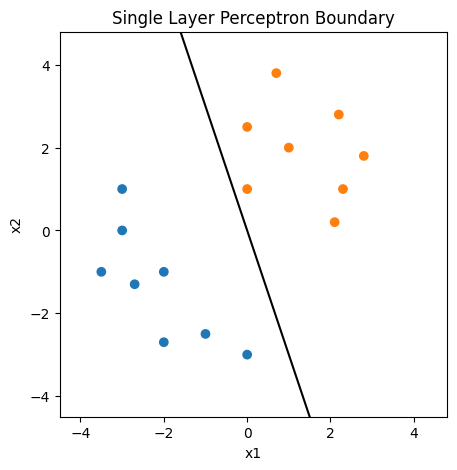

In [ ]:
plot_data(X_train, y_train, title='Single Layer Perceptron Boundary',
          w=slp.w[1:], b=slp.w[0])

### Ширина зазора
Персептрон перестает искать разделяющую границу, как только все объекты
оказываются правильно классифицированы. Такая граница может не быть
оптимальной с точки зрения ширины зазора (обобщающей способности алгоритма).

In [ ]:
slp.predict(X_test)[0], y_test

(array([-1, -1]), array([ 1, -1]))

Сравните результат выше с границей, построенной на тех же данных методом
опорных векторов.

## Адаптивный линейный нейрон
Заменим функцию Хевисайда на линейную функцию

$$ g(z) = g(\mathbf w^\top \mathbf x) = \mathbf w^\top \mathbf x $$

В этом случае мы можем определить уровень ошибки алгоритма как сумму
квадратов отклонений прогнозных значений от метки класса.

$$ J(\mathbf w) = \frac{1}{2} \sum_{i=1}^N (y_i-g(z)_i)^2 $$

Уточним, что $g(z) \in \mathbb{R}.$ Найти минимум $J(\mathbf w)$ можно методом
градиентного спуска

$$ \Delta \mathbf{w} = -\eta \nabla J(\mathbf{w}) $$

или, для одного параметра, $w_j$

$$ \Delta w_j = -\eta \frac{\partial J}{\partial w_j} $$

Найдем частные производные

$$ \begin{gather} \begin{array}{rl} \frac{\partial J}{\partial w_j} =& \frac{\partial }
{\partial w_j} \frac{1}{2} \sum_{i=1}^N (y_i-g(z)_i)^2 \\ =& \frac{1}{2}
\sum_{i=1}^N \frac{\partial}{\partial w_j} (y_i-g(z)_i)^2 \\ =& \frac{1}{2}
\sum_{i=1}^N 2 (y_i-g(z)_i) \frac{\partial}{\partial w_j} (y_i-g(z)_i) \\ =&
\sum_{i=1}^N (y_i-g(z)_i) \frac{\partial} {\partial w_j} \big (y_i-\sum_{j=1}^n w_j
x_{ij} \big) \\ =& \sum_{i=1}^N (y_i-g(z)_i)(-x_{ij}) \end{array} \end{gather} $$

Тогда правило обновления весов можно определить как

$$ \Delta w_j = -\eta \frac{\partial J}{\partial w_j} = -\eta \sum_{i=1}^N (y_i-g(z)_i)(-
x_{ij}) = \eta \sum_{i=1}^N (y_i-g(z)_i)x_{ij} $$

или, в векторизованной форме,

$$ \Delta \mathbf w = \eta \odot X^\top (\mathbf y-g(\mathbf z)) $$

$$ \mathbf w := \mathbf w + \Delta \mathbf w $$

Такое правило обучения называется **дельта-правилом** (delta-rule), а сам
алгоритм — **адаптивным линейным нейроном** (ADALINE).

Приведем код на Питоне.

Full-batch gradient descent

In [ ]:
class AdalineGD:

  def __init__(self, eta=0.01, epochs=50):
    self.eta = eta
    self.epochs = epochs
    self.w = None
    self.loss_history = []

  def fit(self, X, y):

    X = np.c_[np.ones((len(X), 1)), X]
    self.w = np.zeros(X.shape[1])

    for i in range(self.epochs):
      errors = (y - np.dot(X, self.w))
      self.w += self.eta * X.T.dot(errors)
      loss = (errors**2).sum() / 2
      self.loss_history.append(loss)

    return self

  def predict(self, X):
    X = np.c_[np.ones((len(X), 1)), X]
    y_pred = np.where(np.dot(X, self.w) > .0, 1, -1)

    return y_pred

In [ ]:
adaline_gd = AdalineGD().fit(X_train, y_train)

In [ ]:
accuracy_score(y_train, adaline_gd.predict(X_train))

1.0

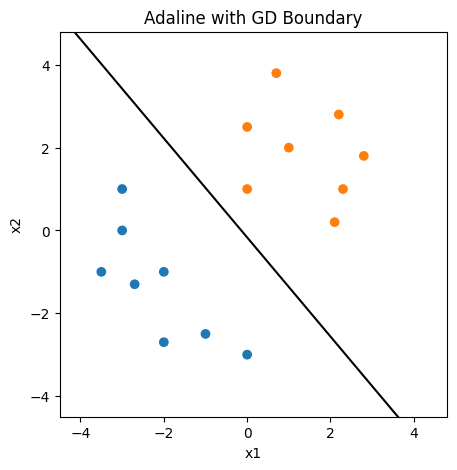

In [ ]:
plot_data(X_train, y_train, title='Adaline with GD Boundary',
          w=adaline_gd.w[1:], b=adaline_gd.w[0])

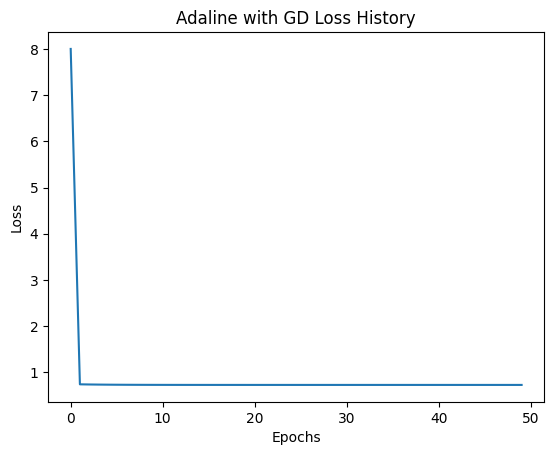

In [ ]:
plt.plot(adaline_gd.loss_history)
plt.title('Adaline with GD Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

Выше мы обновляли веса на основе всех объектов обучающей выборки (full-batch gradient descent).

Обновлять параметры можно после предъявления одного (случайного) объекта. В
этом случае речь идет о стохастическом градиентном спуске (stochastic gradient
descent, SGD).

Stochastic gradient descent

In [ ]:
class AdalineSGD:

  def __init__(self, eta=0.01, epochs=50):
    self.eta = eta
    self.epochs = epochs
    self.w = None
    self.loss_history = []

  def fit(self, X, y):

    X = np.c_[np.ones((len(X), 1)), X]
    self.w = np.zeros(X.shape[1])

    for i in range(self.epochs):
      for xi, yi in zip(X,y):
        errors = (yi - np.dot(xi, self.w))
        self.w += self.eta * xi.T.dot(errors)

      loss = ((y - np.dot(X, self.w))**2).sum() / 2
      self.loss_history.append(loss)

    return self

  def predict(self, X):
    X = np.c_[np.ones((len(X), 1)), X]
    y_pred = np.where(np.dot(X, self.w) > .0, 1, -1)

    return y_pred

In [ ]:
accuracy_score(y_train, AdalineSGD().fit(X_train, y_train).predict(X_train))

1.0

Помимо ширины зазора еще одним ограничением персептрона Розенблатта
является невозможность найти границу линейно неразделимых данных.

## Линейно неразделимые данные
Сведем линейно неразделимые данные к построению функции исключающего
ИЛИ-НЕ (XNOR).

![](https://drive.google.com/uc?export=view&id=1pk7tEWL3yburibxQRUEimpo9A3AfLNn2)

Приведем таблицу истинности.

![](https://drive.google.com/uc?export=view&id=1-YuTbkZ0pPVuLp4CJ-CRwfe2GZFrTEy4)


### Полиномиальные коэффициенты
Одним из решений было бы нелинейное преобразование признаков, как в случае
полиномиальной логистической регрессии. В задаче исключающего ИЛИ-НЕ
достаточно добавить признак $x_1x_2.$

$$ x_1 \odot x_2 = w_0x_0 + w_1x_1 + w_2x_2 + w_3x_1x_2, $$

где $ \odot $ — оператор исключающего ИЛИ-НЕ. Найдем оптимальные веса с
помощью персептрона Розенблатта.

## Исключающее ИЛИ-НЕ

In [ ]:
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([1, -1, -1, 1])

In [ ]:
slp_xnor = Perceptron(const=1e-10).fit(X_train, y_train)
accuracy_score(y_train, slp_xnor.predict(X_train)[0])

0.5

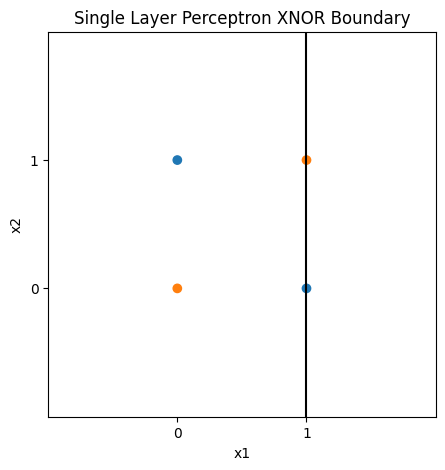

In [ ]:
plot_data(X_train, y_train, title='Single Layer Perceptron XNOR Boundary',
          w=slp_xnor.w[1:], b=slp_xnor.w[0], ticks = [0,1])

### Полиномиальные признаки

In [ ]:
# добавим x1 * x2 (третий столбец)
X_train = np.array([[0, 0, 0],
                    [0, 1, 0],
                    [1, 0, 0],
                    [1, 1, 1]])

y_train = np.array([1, -1, -1, 1])

In [ ]:
slp_poly = Perceptron(const=1e-10).fit(X_train, y_train)
accuracy_score(y_train, slp_poly.predict(X_train)[0])

1.0

Вначале посмотрим на разделяющую гиперплоскость в трехмерном признаковом
пространстве $\mathcal{H}.$

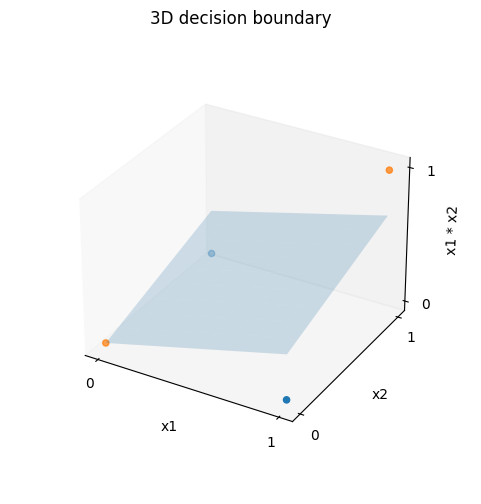

In [ ]:
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')

# выведем данные
ax.scatter3D(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train,
             cmap=colors.ListedColormap(clrs))

# выведем разделяющую гиперплоскость
x = np.linspace(0,1,10)
y = np.linspace(0,1,10)

# ax + by + cz = d
d,a,b,c = slp_poly.w
xx,yy = np.meshgrid(x,y)
Z = (d - a*xx - b*yy) / c
ax.plot_surface(xx, yy, Z, alpha=0.2)

ticks = [0, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_title('3D decision boundary')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x1 * x2')
ax.grid(False)
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.show()

Также выведем решающую границу в изначальном двумерном пространстве
$\mathcal{L}.$

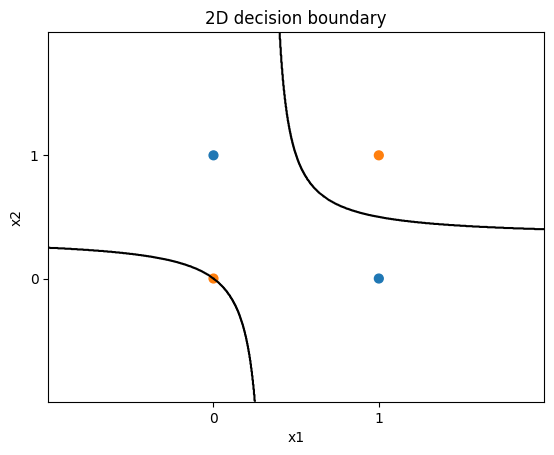

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, s=40, cmap=colors.ListedColormap(clrs))

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))
Z = slp_poly.predict(np.c_[xx.ravel(), yy.ravel(), xx.ravel() * yy.ravel()])[0]
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels = [0], colors = ['k'])

ticks = [0, 1]
plt.xticks(ticks)
plt.yticks(ticks)
plt.title('2D decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

Ожидаемо, линейной границе в $\mathcal{H}$ соответствует нелинейная граница в
$\mathcal{L}.$

Заметим, что с ростом количества признаков и степени полинома итоговое
количество признаков, а значит и «затратность» алгоритма будут расти.

Для полинома $n$-ой степени с одним признаком формула выглядит следующим
образом.

$$ y = \sum^n_{j=0} w_j x^j $$

Например, полином второй степени будет иметь три коэффициента.

$$ y = w_0 + w_{1}x + w_{2}x^2 $$

Полином второй степени с двумя признаками будет иметь уже шесть
коэффициентов.

$$ y = w_{0} + w_{1}x_1 + w_{2}x_2 + w_{3} x_1^2 + w_{4} x_1x_2 + w_{5} x_2^2$$

В целом, количество полиномиальных коэффициентов $K$ можно рассчитать по
формуле.

$$ K(n, d) = C(n+d, d), $$
где,
* $n$ — количество линейных признаков;
* $d$ — степень полинома;
* $C$ — количество возможных сочетаний.

Используя пример выше, получим

$$ K(2, 2) = C(4, 2) = 6 $$

Полином третьей степени на основе десяти линейных признаков уже потребует
создать 286 коэффициентов.

$$ K(10, 3) = C(13, 10) = 286 $$

Если речь идет о картинках 28 х 28 пикселей, то после «вытягивания» каждой
картинки у нас появится датасет с 784 признаками. Значит, количество членов
полинома второй степени составит

$$ K(784, 2) = C(786, 2) = 308 505 $$

Замечу, что примерное количество признаков полинома второй степени также
можно рассчитать по формуле $ \frac{(n)^2}{2} $, то есть $ \frac{(784)^2}{2} = 307
328. $


### Многослойный персептрон

Альтернативным решением было бы использование нескольких «слоев»
персептрона или **многослойный персептрон** (multilayer perceptron, MLP).

В самом деле, используя лишь один скрытый слой из двух нейронов, несложно
подобрать подходящие веса (функцией активации $g(z)$ снова будет функция
Хевисайда).

![](https://drive.google.com/uc?export=view&id=1XvqId_RJ7PHq7hDIoWH3wCYjd12OkeeW)

На каждом последующем слое нейросеть строит все более сложную зависимость:
* первый скрытый нейрон обучился зависимости И;
* второй нейрон дополнил это знание зависимостью ИЛИ-НЕ; и вместе
* они обучились выдавать результат исключающего ИЛИ-НЕ.

Приведем таблицу истинности.

![](https://drive.google.com/uc?export=view&id=1Gn5rcJN58_Idbi-K3eOh_T-cVwdhjRwR)

Создадим классификатор на основе многослойного персептрона с помощью класса
MLPClassifier библиотеки sklearn.





In [ ]:
# вернемся к исходным данным XNOR
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([1, 0, 0, 1])

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(2),
                    # будем использовать сигмоиду в качестве
                    # функции активации
                    activation='logistic',
                    solver='lbfgs',
                    random_state=1).fit(X_train, y_train)

Оптимизация многослойного персептрона в примере выше происходит
квазиньютоновским методом LBFGS. Его рассмотрение выходит за рамки
сегодняшнего занятия.

In [ ]:
accuracy_score(y_train, mlp.predict(X_train))

1.0

Посмотрим на нелинейную решающую границу на **исходно**м представлении
данных (data representation).

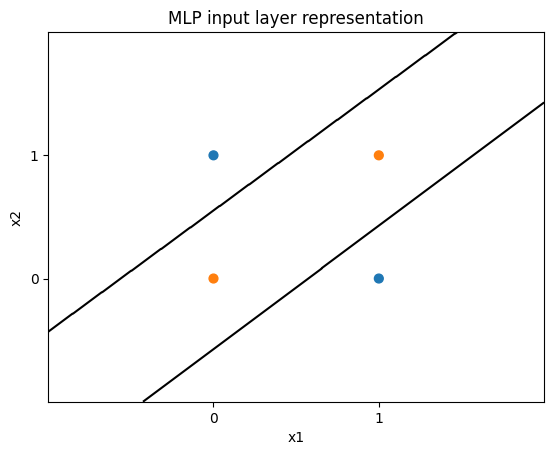

In [ ]:
# выведем исходное представление данных
plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, s=40, cmap=colors.ListedColormap(clrs))

# выведем решающую границу
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
XX, YY = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))
Z = mlp.predict(np.c_[XX.ravel(), YY.ravel()])
Z = Z.reshape(XX.shape)
plt.contour(XX, YY, Z, levels = [0], colors = ['k'])

ticks = [0, 1]
plt.xticks(ticks)
plt.yticks(ticks)
plt.title('MLP input layer representation')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

Кроме этого, в данном случае мы можем посмотреть, какому представлению
данных обучились нейроны **скрытого** слоя.

Скрытое представление данных

In [ ]:
from scipy.special import expit

In [ ]:
# умножим веса первого слоя на матрицу данных, добавим смещение и
# пропустим через сигмоиду
hidden = expit(np.dot(X_train, mlp.coefs_[0]) + mlp.intercepts_[0])
np.round(hidden)

array([[1., 0.],
       [0., 0.],
       [1., 1.],
       [1., 0.]])

Несложно заметить, что первое и четвертое наблюдения теперь имеют одни и те же
координаты `[1, 0]`. Другими словами, данные стали линейно разделимыми.

Убедимся в этом, рассчитав метки классов на выходном слое,

In [ ]:
np.heaviside(np.dot(hidden, mlp.coefs_[1]) + mlp.intercepts_[1], .5)

array([[1.],
       [0.],
       [0.],
       [1.]])

а также выведя на графике скрытое представление данных и решающую границу,
построенную для этого представления.

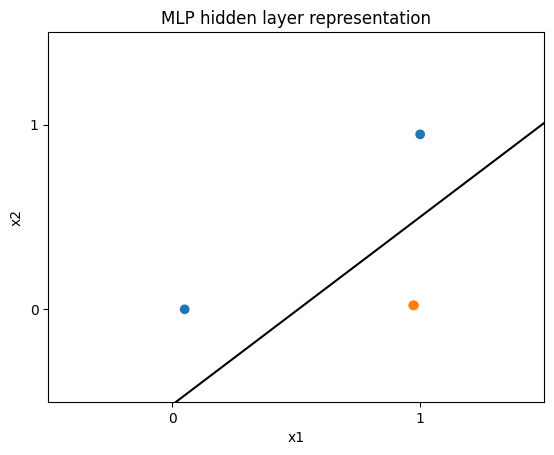

In [ ]:
# выведем скрытое представление данных
plt.scatter(hidden[:, 0], hidden[:, 1], c=y_train,
            cmap=colors.ListedColormap(clrs))

# рассчитаем наклон и сдвиг решающей границы
# на основе весов скрытого слоя
hyperplane_slope = -mlp.coefs_[1][0]/mlp.coefs_[1][1]
hyperplane_intercept = -mlp.intercepts_[1]/mlp.coefs_[1][1]

# построим уравнение решающей границы и выведем границу на графике
ax_min, ax_max = -.5, 1.5
xx = np.linspace(ax_min, ax_max)
yy = hyperplane_slope*xx + hyperplane_intercept
hyperplane = np.array(list(zip(xx, yy)))
plt.plot(hyperplane[:, 0], hyperplane[:, 1], 'k-')

ticks=[0,1]
plt.xticks(ticks)
plt.yticks(ticks)
plt.xlim(ax_min, ax_max)
plt.ylim(ax_min, ax_max)
plt.title('MLP hidden layer representation')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# Список литературы

* Воронцов К.В. Лекции по искусственным нейронным сетям (http://www.ccas.ru/voron/download/NeuralNets.pdf)
* McCulloch W. S., Pitts W. A logical calculus of the ideas immanent in nervous
activity (https://www.cs.cmu.edu/~epxing/Class/10715/reading/McCulloch.and.Pitts.pdf), 1943
* Rosenblatt F., The perceptron, a perceiving and recognizing automaton, 1957
* Widrow B. et al. Adaptive «Adaline» neuron using chemical «memistors» (https://isl.stanford.edu/~widrow/papers/t1960anadaptive.pdf), 1960
* Olah C., Neural Networks, Manifolds, and Topology (https://colah.github.io/posts/2014-03-NN-Manifolds-Topology/)
